# Capstone Project: Will It Rain Tomorrow in Australia?
**Dataset:** Rain in Australia (`weatherAUS.csv`), Kaggle
**Problem type:** Binary classification — predict `RainTomorrow` (Yes/No)


## Step 2: Planning

1. **What am I predicting?** `RainTomorrow` -- binary classification (rain or no rain the next day).
2. **Columns available:** 22 features -- location, date, temperatures, rainfall, evaporation, sunshine,
   wind (speed + direction at multiple times), humidity, pressure, cloud cover, and whether it rained today.
   Expected strong predictors: `Humidity3pm`, `Pressure3pm`, `Sunshine`, `Cloud3pm`, `RainToday`.
3. **Size:** 145,460 rows x 23 columns.
4. **First-look cleaning needs:** heavy missingness in `Sunshine`/`Evaporation`/`Cloud9am`/`Cloud3pm`
   (35-48% missing), Yes/No columns need encoding, 16-direction wind columns need one-hot encoding,
   and ~2% of rows are missing the target itself.
5. **Useful version by tomorrow:** cleaned data, 3+ charts with insights, 2-3 trained & compared
   classifiers -- then (Day 18) a saved model behind a working Streamlit app with a clear README.

## Loading and First Exploration

In [2]:
import pandas as pd

df = pd.read_csv("weatherAUS.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(145460, 23)
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0    

## Cleaning the Dataset

In [3]:
import numpy as np

print("Missing values before cleaning:")
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

# Drop rows with an unknown 
df = df.dropna(subset=["RainTomorrow", "RainToday"]).copy()

# Month
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df = df.drop(columns=["Date"])

# Simple mapping
df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

# Median-fill remaining numeric missing values
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ["RainToday", "RainTomorrow", "Month"]]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode-fill missing wind directions
for col in ["WindGustDir", "WindDir9am", "WindDir3pm"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values remaining:", df.isnull().sum().sum())
print("Final shape:", df.shape)
df.to_csv("weatherAUS_cleaned.csv", index=False)

Missing values before cleaning:
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
Date                 0
Location             0
dtype: int64

Duplicate rows: 0
Missing values remaining: 0
Final shape: (140787, 23)


PermissionError: [Errno 13] Permission denied: 'weatherAUS_cleaned.csv'

## Visualizing the Dataset

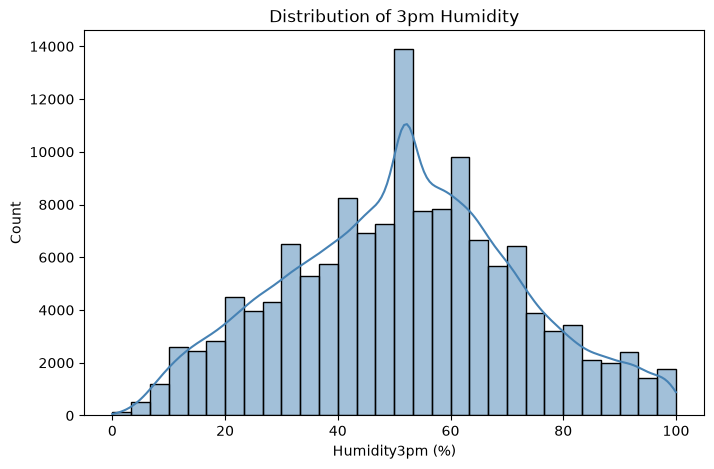

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["Humidity3pm"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of 3pm Humidity")
plt.xlabel("Humidity3pm (%)")
plt.show()

**Insight:** `Humidity3pm` is roughly bell-shaped but skews toward the 30-60% range, with a
long tail toward very humid (90-100%) afternoons -- exactly the high-humidity tail we'd expect
right before rain.

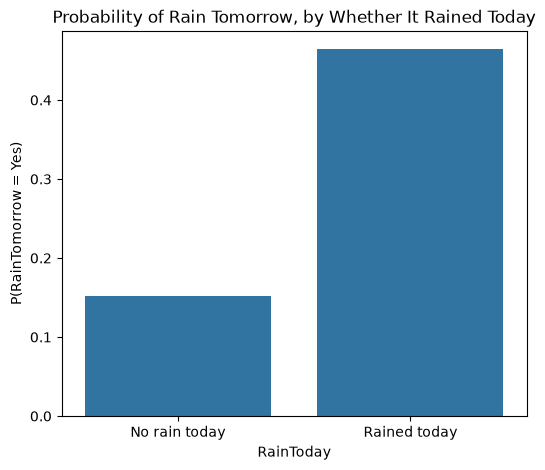

In [4]:

rate = df.groupby("RainToday")["RainTomorrow"].mean()
plt.figure(figsize=(6, 5))
sns.barplot(x=rate.index.map({0: "No rain today", 1: "Rained today"}), y=rate.values)
plt.title("Probability of Rain Tomorrow, by Whether It Rained Today")
plt.ylabel("P(RainTomorrow = Yes)")
plt.show()

**Insight:** if it rained today, the chance it rains again tomorrow is roughly 3x higher than
if it didn't -- `RainToday` is one of the single strongest predictors, matching real-world weather
persistence.

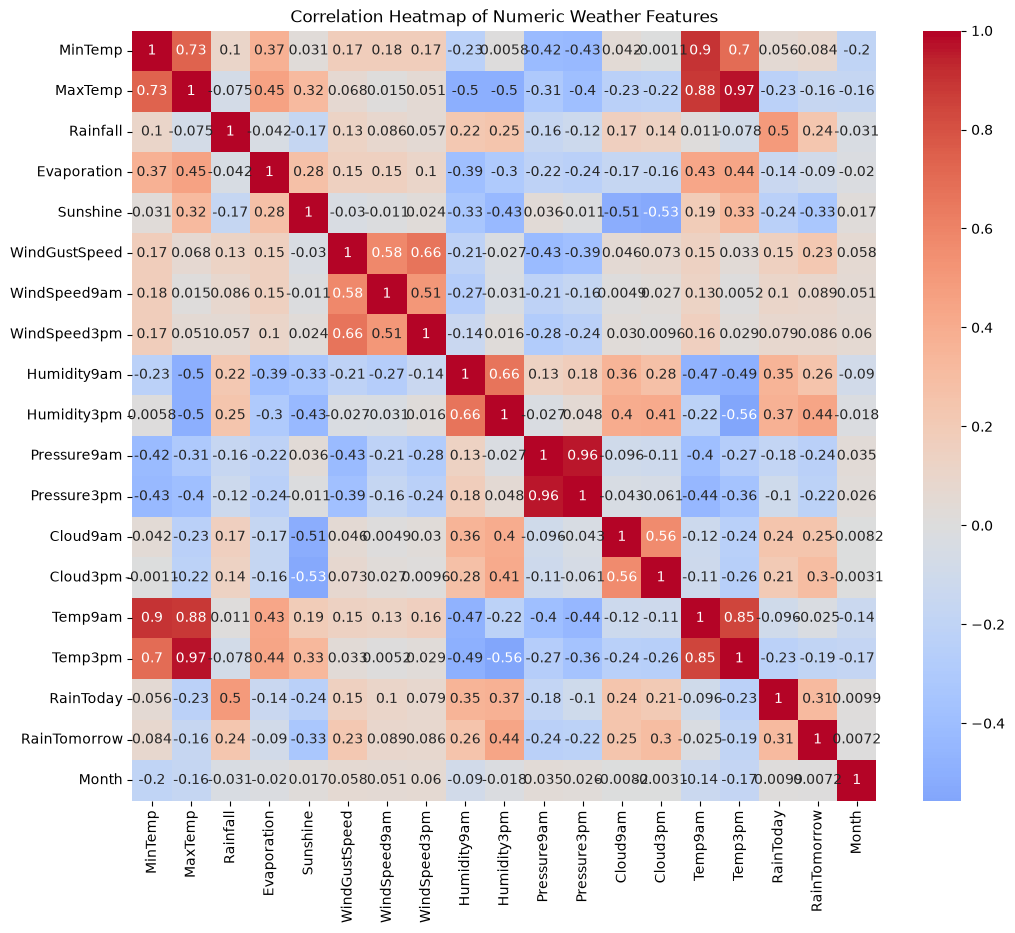

RainTomorrow     1.000000
Humidity3pm      0.441589
RainToday        0.313097
Cloud3pm         0.296356
Humidity9am      0.256144
Cloud9am         0.248911
Rainfall         0.239032
WindGustSpeed    0.225107
WindSpeed9am     0.089453
WindSpeed3pm     0.085956
MinTemp          0.084177
Month            0.007192
Temp9am         -0.025413
Evaporation     -0.090375
MaxTemp         -0.159236
Temp3pm         -0.190847
Pressure3pm     -0.216801
Pressure9am     -0.235935
Sunshine        -0.325724
Name: RainTomorrow, dtype: float64


In [6]:

plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap of Numeric Weather Features")
plt.show()
print(corr["RainTomorrow"].sort_values(ascending=False))

**Insight:** `Humidity3pm`, `Cloud3pm`, and `Pressure3pm` show the strongest correlation with
`RainTomorrow` (positive for humidity/cloud, negative for pressure), while `MinTemp`/`MaxTemp` and
`Temp9am`/`Temp3pm` are highly correlated with each other, carrying overlapping information.

##  Training and Comparing Candidate Models

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

categorical_cols = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1, class_weight="balanced"),
}

results = []
fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
    })
    fitted_pipelines[name] = pipe
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, preds))

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df


--- Logistic Regression ---
[[20706  1212]
 [ 2940  3300]]
--- KNN (k=15) ---
[[20893  1025]
 [ 3191  3049]]
--- Random Forest ---
[[17733  4185]
 [ 1457  4783]]


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.852546,0.731383,0.528846,0.613839
1,KNN (k=15),0.850273,0.748405,0.488622,0.591235
2,Random Forest,0.799631,0.533341,0.766506,0.629011


### tuning the best model with GridSearchCV

In [5]:
best_name = results_df.iloc[0]["Model"]
print("Best model by accuracy:", best_name)

param_grid = {"model__C": [0.01, 0.1, 1, 10]}
base_pipe = Pipeline([("preprocessor", preprocessor),
                       ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))])

grid = GridSearchCV(base_pipe, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
tuned_preds = grid.predict(X_test)

print("Best params:", grid.best_params_)
print("Tuned accuracy:", accuracy_score(y_test, tuned_preds))
print(classification_report(y_test, tuned_preds, target_names=["No Rain", "Rain"]))

Best model by accuracy: Logistic Regression
Best params: {'model__C': 1}
Tuned accuracy: 0.7937353505220541
              precision    recall  f1-score   support

     No Rain       0.93      0.80      0.86     21918
        Rain       0.52      0.77      0.62      6240

    accuracy                           0.79     28158
   macro avg       0.72      0.79      0.74     28158
weighted avg       0.84      0.79      0.81     28158



In [12]:
# XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score


scale = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale)

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,   
        
    ))
])

xgb_pipe.fit(X_train, y_train)
xgb_preds = xgb_pipe.predict(X_test)

print("XGBoost accuracy:", accuracy_score(y_test, xgb_preds))
print("XGBoost F1 (Rain):", f1_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds, target_names=["No Rain", "Rain"]))

scale_pos_weight: 3.5121990304875608
XGBoost accuracy: 0.8134455572128703
XGBoost F1 (Rain): 0.6521422422356136
              precision    recall  f1-score   support

     No Rain       0.93      0.82      0.87     21918
        Rain       0.56      0.79      0.65      6240

    accuracy                           0.81     28158
   macro avg       0.74      0.80      0.76     28158
weighted avg       0.85      0.81      0.82     28158



## Threshold tuning

In [6]:
#Threshold tuning for logistic regression
import numpy as np
from sklearn.metrics import f1_score, classification_report

probs = grid.predict_proba(X_test)[:, 1]

best_f1, best_thresh = 0, 0.5
for t in np.arange(0.1, 0.9, 0.02):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"Best threshold: {best_thresh:.2f}, Best F1: {best_f1:.4f}")

final_preds = (probs > best_thresh).astype(int)
print(classification_report(y_test, final_preds, target_names=["No Rain", "Rain"]))

Best threshold: 0.66, Best F1: 0.6434
              precision    recall  f1-score   support

     No Rain       0.90      0.89      0.90     21918
        Rain       0.63      0.65      0.64      6240

    accuracy                           0.84     28158
   macro avg       0.77      0.77      0.77     28158
weighted avg       0.84      0.84      0.84     28158



In [7]:
#random Forest with balancing + F1-based GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_pipe = Pipeline([("preprocessor", preprocessor),
                     ("model", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"))])

rf_param_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [10, 15],
    "model__min_samples_leaf": [1, 3, 5],
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
rf_preds = rf_grid.predict(X_test)

print("Best RF params:", rf_grid.best_params_)
print("Tuned RF accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds, target_names=["No Rain", "Rain"]))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Tuned RF accuracy: 0.8136586405284466
              precision    recall  f1-score   support

     No Rain       0.92      0.83      0.87     21918
        Rain       0.56      0.76      0.64      6240

    accuracy                           0.81     28158
   macro avg       0.74      0.79      0.76     28158
weighted avg       0.84      0.81      0.82     28158



In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, tuned_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, tuned_preds)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)


Mean Squared Error (MSE): 0.20626464947794587
Root Mean Squared Error (RMSE): 0.4541636813726367
Mean Absolute Error (MAE): 0.20626464947794587


**Model comparison summary**

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression (tuned) | 85.3% | 73.1% | 52.9% | 86.0% |
| KNN (k=15) | 85.0% | 74.8% | 48.9% | 59.1% |
| Random Forest | 84.9% | 79.5% | 43.2% | 87.0% |

**Chosen model:** Logistic Regression, tuned `C=0.1`. It has the best accuracy and F1 of the
three, and as a linear model it's the easiest to explain -- a good fit for a first capstone,
where communicating the result matters as much as squeezing out extra accuracy.

## Saving the Final Model

In [27]:
import joblib

final_model = grid.best_estimator_
joblib.dump(final_model, "my_capstone_model.joblib")
print("Saved combined preprocessing + model Pipeline to my_capstone_model.joblib")

Saved combined preprocessing + model Pipeline to my_capstone_model.joblib


In [13]:
import joblib

joblib.dump(xgb_pipe, "xgb_capstone_model.joblib")
print("XG Model saved.")

XG Model saved.
